In [15]:
import os
import math
import time
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Decoder_CLasses.ContinuousVoronoiDecoder import ContinuousVoronoiDecoder
from Utils.CADDomainVisualizer import CADDomainVisualizer
from Utils.CADVisualizer   import CADVisualizer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


Code Directory: /home/arash/HVD_SeedsBase
Test Step files Directory: /home/arash/HVD_SeedsBase/Testparts
device: cuda
PyVista backend: trame


Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    :  - Label 'Shapes/Document' (2D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 30%] Meshing curve 2 (BSpline)
Info    : [ 60%] Meshing curve 3 (Circle)
Info    : [ 80%] Meshing curve 4 (BSpline)
Info    : Done meshing 1D (Wall 0.00027528s, CPU 0.000299s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Cylinder, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0474786s, CPU 0.048015s)
Info    : 2771 nodes 5544 elements
Info    : Clearing all models and views...
Info    : Done clearing all models and views

=== Active Face Info ===
XYZ bounds:
  X: [-0.000000, 10.000000]  span=10.000000
  Y: [-0.127468, 2.100919]  span=2.228387
  Z: [-2.032622, 1.938721]  span=3.971343

UV bounds:
  U: [-0.039832, 3.264132]
  V: [-5.000000, 5.000000]

Periodic:
  U periodic: False
  V periodic: False



Widget(value='<iframe src="http://localhost:41895/index.html?ui=P_0x72137dd63ac0_15&reconnect=auto" class="pyv…

Widget(value='<iframe src="http://localhost:41895/index.html?ui=P_0x72137dd3a290_16&reconnect=auto" class="pyv…

Widget(value='<iframe src="http://localhost:41895/index.html?ui=P_0x72137dd3b3a0_17&reconnect=auto" class="pyv…

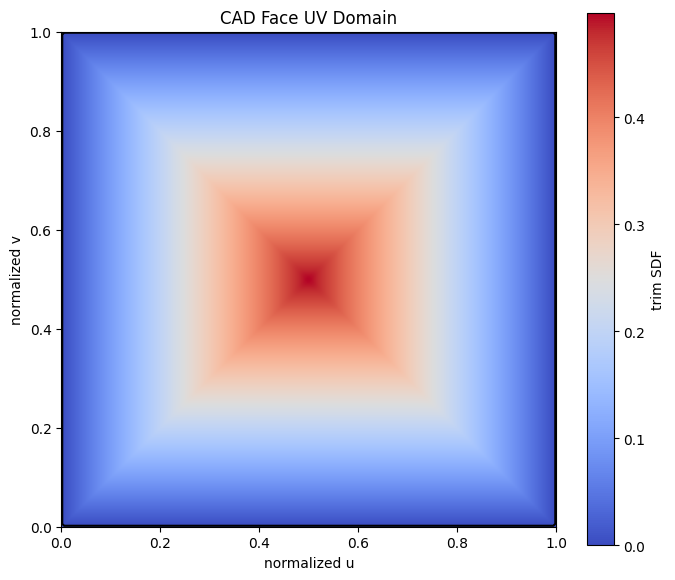

In [18]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"
FreeFormSurf4 = TesPartsDir / "FreeForm4.stp"
FreeFormBench = TesPartsDir / "FreeFormBench.stp"
FreeSharp1 = TesPartsDir / "FreeSharp1.stp"
FreeSharp2 = TesPartsDir / "FreeSharp2.stp"
SeatBr = TesPartsDir / "SeatBr.stp"
MouseBot = TesPartsDir / "MouseBot.stp"

shape_path = CircularSurf1

Face_Cad = CADTensorGenerator(
    device=device,
    seed_domain_mask_res=512,
)

cad_domain, face_mesh = Face_Cad.generate_from_file(shape_path)

dx,dy,dz = Face_Cad.print_face_info();

viz = CADDomainVisualizer(Face_Cad)

viz.plot_uv_domain()

viz.show_3d(
    res_u=200,
    res_v=200,
    show_edges=True,
)

# --------------------------------------------------
# Visualize Gmsh mesh nodes as point cloud
# --------------------------------------------------

points_xyz = face_mesh["points_xyz"]

pts = points_xyz.detach().cpu().numpy()

cloud = pv.PolyData(pts)

plotter = pv.Plotter()
plotter.add_mesh(
    cloud,
    render_points_as_spheres=True,
    point_size=6,
)
plotter.show()

# --------------------------------------------------
# Visualize actual Gmsh triangular surface mesh
# --------------------------------------------------

points = face_mesh["points_xyz"].detach().cpu().numpy()
faces = face_mesh["pv_faces"].detach().cpu().numpy()

mesh = pv.PolyData(points, faces)

plotter = pv.Plotter()
plotter.add_mesh(
    mesh,
    show_edges=True,
)
plotter.show()

In [ ]:
def random_seeds_min_dist(N, min_dist=0.08, seed=1, max_tries=10000, device="cpu"):
    torch.manual_seed(seed)

    seeds = []
    tries = 0

    while len(seeds) < N and tries < max_tries:
        p = torch.rand(2, device=device)

        if len(seeds) == 0:
            seeds.append(p)
        else:
            current = torch.stack(seeds, dim=0)
            d = torch.linalg.norm(current - p[None, :], dim=-1)

            if d.min() >= min_dist:
                seeds.append(p)

        tries += 1

    if len(seeds) < N:
        raise RuntimeError(
            f"Could only generate {len(seeds)} seeds with min_dist={min_dist}."
        )

    return torch.stack(seeds, dim=0)

In [ ]:
dec = ContinuousVoronoiDecoder(
    return_xyz=False,
    min_area=1e-3,
    duplicate_merge_sigma = 0.005,
    tau_area=1e-4,
    min_seed_dist=0.01,
    tau_close=0.001,
)

for i in range(1,2):
    N=10
    seeds = random_seeds_min_dist(
        N=N,
        min_dist=0.008,
        seed=i*21,
        device="cpu",
    )

    seeds = seeds.detach().clone().requires_grad_(True)

    out = dec(
        seeds,
        topology_mode="scipy",
        return_xyz=False,
    )

    graph = out["graph"]

    # print("interior vertices:", out["vertices_uv"].shape)
    # print("finite edges:", out["edges"]["edge_index"].shape)
    # print("boundary rays:", out["boundary_rays"].shape)

    # print("graph nodes:", graph["nodes_uv"].shape)
    # print("graph edges:", graph["edge_index"].shape)
    # print("node type:", graph["node_type"])
    # print("boundary nodes:", graph["num_boundary_nodes"])


    loss = graph["nodes_uv"].sum()
    loss.backward()
    print("grad finite:", torch.isfinite(seeds.grad).all())

    # dec.plot_generatedN_graph_debug(seeds,out,Face_Cad,True,True,12,False)
    dec.plot_scipy_vs_generated_graph(seeds,out,Face_Cad,True,True,8,False);

In [17]:
# Edge-type-aware UV sampling keeps shell edges on the CAD boundary.
u_periodic = bool(cad_domain["u_periodic"])
v_periodic = bool(cad_domain["v_periodic"])

curves_uv = dec.sample_graph_edge_curves_uv(
    seeds_uv=seeds,
    graph=out["graph"],
    n_samples=128,
    u_periodic=u_periodic,
    v_periodic=v_periodic,
)
curves_xyz = dec.sample_smooth_edge_curves_xyz(Face_Cad, curves_uv)

edge_type = out["graph"]["edge_type"]
print(torch.bincount(edge_type))
print(curves_uv.shape)

curves_np = curves_xyz.detach().cpu().numpy()
plotter = pv.Plotter()
edge_colors = {0: "black", 1: "orange", 2: "gray", 3: "orange", 4: "cyan"}
for edge_id, points in enumerate(curves_np):
    polyline = pv.PolyData(points)
    polyline.lines = np.concatenate(([len(points)], np.arange(len(points)))).astype(np.int64)
    plotter.add_mesh(
        polyline,
        color="gray",
        line_width=3 if int(edge_type[edge_id]) == 4 else 2,
    )
plotter.show()


tensor([227,  41,   0,   0,  45])
torch.Size([313, 128, 2])


Widget(value='<iframe src="http://localhost:41895/index.html?ui=P_0x72137db0b4f0_14&reconnect=auto" class="pyv…

In [19]:
Include_FEM= True
LoadingCase = "Torsion in Y"  # "Tensile" or "Compression"

voxel_size = (dx+dy+dz)/50
fixed_height_shell= voxel_size*2
tangential_tol = voxel_size*0.8

if(Include_FEM):
    # ============================================================
    # Choose ONE load case below.
    # Comment out the other two sections.
    # ============================================================


    # ------------------------------------------------------------
    # 1) Tensile / Compression
    # ------------------------------------------------------------
    # Use this when you want to pull or push the shell along one axis.
    #
    # load_case:
    #   "tensile_compression", "tensile", or "compression"
    #
    # BC_dir:
    #   Axis of loading: "x", "y", or "z".
    #   The min side of this axis is fixed.
    #   The max side of this axis receives the force.
    #
    # Load_magnitude:
    #   Positive value pulls in +BC_dir direction.
    #   Negative value pushes/compresses in -BC_dir direction.
    #
    # # Example:
    shell_problem = ThickenShell(
        thickness=fixed_height_shell,
        BC_dir="x",
        Load_magnitude=0.1,
        voxel_size=voxel_size,
        extra_layers=1,
        tensors=face_mesh,
        tangential_tol=tangential_tol,
        load_case="tensile_compression",
    )


    # ------------------------------------------------------------
    # 2) Three-Point Bending
    # ------------------------------------------------------------
    # Use this when you want two supports at the ends and a load in the middle.
    #
    # load_case:
    #   "three_point_bending", "threepoint_bending", or "3_point_bending"
    #
    # BC_dir:
    #   Span direction of the part.
    #   Supports are placed at min and max sides of this axis.
    #   The load is applied near the middle of this axis.
    #
    # load_dir:
    #   Direction of the bending force: "x", "y", or "z".
    #
    # Load_magnitude:
    #   Force applied at the middle.
    #   Sign controls direction along load_dir.
    #
    # load_surface_dir:
    #   Optional. Restricts the middle load nodes to one outer surface.
    #   Example: load_surface_dir="z", load_surface_side="max"
    #   means apply the middle force only on the top z surface.
    #
    # load_surface_side:
    #   "min" or "max" side of load_surface_dir.
    #
    # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="x",
    #     Load_magnitude=-0.1,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=tensors,
    #     tangential_tol=tangential_tol,
    #     load_case="three_point_bending",
    #     load_dir="z",
    #     load_surface_dir="z",
    #     load_surface_side="max",
    # )


    # ------------------------------------------------------------
    # 3) Torsion / Twist
    # ------------------------------------------------------------
    # Use this when you want to twist the shell around one axis.
    #
    # load_case:
    #   "torsion", "twist", or "torque"
    #
    # BC_dir:
    #   Axis of twisting: "x", "y", or "z".
    #
    # fixed_side:
    #   Which end of BC_dir is fixed: "min" or "max".
    #
    # force_side:
    #   Which end receives the torque.
    #   Must be opposite to fixed_side.
    #   If omitted, the code automatically chooses the opposite side.
    #
    # Load_magnitude:
    #   Total torque magnitude.
    #   Sign controls twist direction.
    #
    # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="y",
    #     Load_magnitude=0.1,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=tensors,
    #     tangential_tol=tangential_tol,
    #     load_case="torsion",
    #     fixed_side="min",
    #     force_side="max",
    # )

    # shell_problem =None
    # fem =None
    fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)
    shell_problem.debug_voxel_stats()
    loading_img = shell_problem.show_voxels_surface_and_bc(
        return_img=True,
        off_screen=True,
        window_size=(560, 430),
        show=True,
    )
else:
    shell_problem = None
    fem = None
    loading_img = None   

=== Voxel Stats ===
brep_bbox: {'xmin': -1e-07, 'xmax': 10.0000001, 'ymin': -0.12746830751419996, 'ymax': 2.1009187367176096, 'zmin': -2.0326218088715367, 'zmax': 1.9387214085522233}
mesh: {'nelx': 35, 'nely': 11, 'nelz': 17, 'elemSize': array([0.32399461, 0.32399461, 0.32399461]), 'type': 'grid'}
elem_centers shape: (17, 35, 11, 3)
node_coords shape: (18, 36, 12, 3)
occupied voxels: 1474
total voxels: 6545
occupancy ratio: 0.22521008403361345
voxels with assigned surface samples: 775
occupied voxels with assigned surface samples: 775
voxelized volume: 50.13151580277264
thickness: 0.6479892184662228
voxel_size: 0.3239946092331114
target approx volume (sum(face_areas)*thickness): 42.502322368409715
volume ratio voxel/target: 1.1795006251242732


Widget(value='<iframe src="http://localhost:41895/index.html?ui=P_0x72137dc7dc30_18&reconnect=auto" class="pyv…